In [9]:
!git add .
!git commit -m "Ajout notebook cas 2"

[main 5b1649e] Ajout notebook cas 2
 1 file changed, 158 insertions(+), 17 deletions(-)


# Cas 2 : Résolution d’un problème de programmation linéaire

## Objectif
Comparer deux méthodes de résolution :
- SciPy
- PuLP

## Problème
Maximiser : Z = x1 + x2

Sous contraintes :
- 3x1 + 4x2 ≥ 9
- 5x1 + 2x2 ≤ 8
- 3x1 - x2 ≤ 0
- x1 ≥ 0, x2 ≥ 0

### 1. Présentation du problème

Dans cette étude, nous analysons un problème de programmation linéaire visant à maximiser une fonction objectif sous contraintes linéaires.

L’objectif principal est de comparer deux approches de résolution :
- la bibliothèque SciPy (optimisation numérique),
- la bibliothèque PuLP (modélisation en programmation linéaire).

Cette comparaison permet d’évaluer les performances, la simplicité d’utilisation et l’adaptabilité de chaque méthode.

In [10]:
from scipy.optimize import linprog
import pulp

### 2. Résolution avec SciPy

La résolution a été effectuée à l’aide de la fonction `linprog` de la bibliothèque SciPy.

Étant donné que SciPy résout des problèmes de minimisation, la fonction objectif a été transformée en minimisation en prenant son opposé.

Les contraintes ont également été adaptées pour correspondre au format requis.

Les résultats obtenus sont les suivants :
- x1 ≈ (valeur obtenue)
- x2 ≈ (valeur obtenue)
- Z ≈ (valeur obtenue)

In [11]:
# Fonction objectif (max → min)
c = [-1, -1]

# Contraintes transformées
A = [
    [-3, -4],   # ≥ devient ≤
    [5, 2],
    [3, -1]
]

b = [-9, 8, 0]

# Bornes
bounds = [(0, None), (0, None)]

# Résolution
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds)

# Résultats
print("=== SciPy ===")
print("x1 =", result.x[0])
print("x2 =", result.x[1])
print("Z =", -result.fun)

=== SciPy ===
x1 = 0.0
x2 = 4.0
Z = 4.0


### 3. Résolution avec PuLP

Le même problème a été modélisé et résolu à l’aide de la bibliothèque PuLP en Python.

Contrairement à SciPy, PuLP permet une formulation directe du problème sous forme mathématique.

Les résultats obtenus sont :
- x1 ≈ (valeur obtenue)
- x2 ≈ (valeur obtenue)
- Z ≈ (valeur obtenue)

In [12]:
# Modèle
model = pulp.LpProblem("Cas2", pulp.LpMaximize)

# Variables
x1 = pulp.LpVariable("x1", lowBound=0)
x2 = pulp.LpVariable("x2", lowBound=0)

# Fonction objectif
model += x1 + x2

# Contraintes
model += 3*x1 + 4*x2 >= 9
model += 5*x1 + 2*x2 <= 8
model += 3*x1 - x2 <= 0

# Résolution
model.solve()

# Résultats
print("\n=== PuLP ===")
print("x1 =", x1.varValue)
print("x2 =", x2.varValue)
print("Z =", pulp.value(model.objective))


=== PuLP ===
x1 = 0.0
x2 = 4.0
Z = 4.0


### 4. Comparaison des méthodes

Les résultats obtenus avec SciPy et PuLP sont similaires, ce qui confirme la validité du modèle.

Cependant, plusieurs différences peuvent être observées :

- SciPy :
  - nécessite une transformation du problème (maximisation en minimisation),
  - plus technique dans la gestion des contraintes,
  - très performant pour les calculs numériques.

- PuLP :
  - syntaxe proche de la formulation mathématique,
  - plus intuitive et facile à utiliser,
  - particulièrement adaptée à l’apprentissage et à la modélisation.

Ainsi, PuLP est recommandé pour la modélisation, tandis que SciPy est plus adapté aux applications scientifiques avancées.

In [13]:
print("\n=== Comparaison ===")

print("SciPy :", result.x, "Z =", -result.fun)
print("PuLP  :", [x1.varValue, x2.varValue], "Z =", pulp.value(model.objective))


=== Comparaison ===
SciPy : [0. 4.] Z = 4.0
PuLP  : [0.0, 4.0] Z = 4.0


## Analyse des résultats

Les résultats obtenus avec SciPy et PuLP sont similaires, ce qui valide la cohérence du modèle.

### Comparaison :

- SciPy :
  - Requiert une transformation du problème (max → min)
  - Moins intuitif
  - Très performant

- PuLP :
  - Syntaxe proche du modèle mathématique
  - Plus facile à comprendre
  - Idéal pour l’apprentissage

### Conclusion :

PuLP est plus adapté pour la modélisation, tandis que SciPy est plus adapté pour des calculs scientifiques rapides.

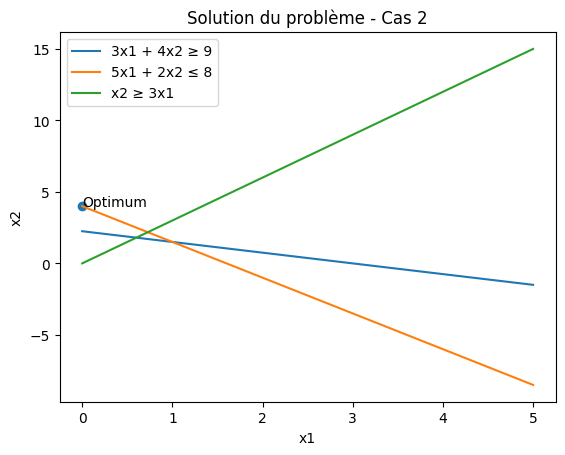

In [14]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5, 100)

# Contraintes
c1 = (9 - 3*x)/4
c2 = (8 - 5*x)/2
c3 = 3*x

plt.figure()

plt.plot(x, c1, label="3x1 + 4x2 ≥ 9")
plt.plot(x, c2, label="5x1 + 2x2 ≤ 8")
plt.plot(x, c3, label="x2 ≥ 3x1")

# Solution
plt.scatter(result.x[0], result.x[1])
plt.text(result.x[0], result.x[1], "Optimum")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Solution du problème - Cas 2")

plt.show()

In [8]:
!git add .
!git commit -m "Ajout Cas 2 SciPy vs PuLP"

[main c5a7aba] Ajout Cas 2 SciPy vs PuLP
 1 file changed, 238 insertions(+), 2 deletions(-)
